# 21 — Pathway Explorer — BPIC17

Combines the process DFG (observed activity transitions) with single-feature sweeps.

**Workflow:**
1. Extract the directly-follows graph (DFG) from the test set and identify **decision points** (activities with >1 distinct successor).
2. The user selects an observed activity pathway (e.g., `['A_Create Application', 'A_Submitted']`).
3. Show the LSTM's prediction at that decision point.
4. Sweep non-activity features (`org:resource`, `case:LoanGoal`, `case:ApplicationType`) to find which values steer the model toward each alternative branch.

Case-level features (`case:LoanGoal`, `case:ApplicationType`) are changed uniformly across all positions.

Note: BPIC17 has a large `org:resource` vocabulary (151 values), so resource sweeps
produce larger heatmaps — only the most discriminating values are shown.

In [11]:
import sys
import os
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [ ]:
import torch
import numpy as np
import pandas as pd

# --- Load dataset ---
data_path = _current / 'encoded_data' / 'BPIC_2017_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Dataset: {len(dataset)} sequences, {n_cat} cat, {n_num} num, seq_len={seq_len}')

# --- Load model ---
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

from src.interpretability.config.bpic17_config import CONFIG
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()

# --- TensorDecoder + activity vocab ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'concept:name'
ACT_IDX = 0
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

# --- Predictor ---
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')
print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}')
print(f'Cat features: {decoder.cat_features}')
print(f'Num features: {decoder.num_features}')

In [13]:
# === Extract observed pathways from dataset ===
# Note: BPIC17 is large (~253K entries), so scanning takes a moment.

# Collect unique cases (keep entry with longest trace per case_id)
cases = {}  # case_id -> (dataset_idx, trace_len)
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)
    if (i + 1) % 50000 == 0:
        print(f'  Scanned {i + 1}/{len(dataset)}, found {len(cases)} unique cases...')

print(f'Unique cases: {len(cases)}')

# Build DFG and pathway index
dfg = {}  # (src_name, tgt_name) -> count
pathway_index = {}  # tuple(act_names) -> [(dataset_idx, trace_len)]

for case_id, (ds_idx, trace_len) in cases.items():
    cat_t = dataset[ds_idx][0]
    src_start = seq_len - trace_len
    acts = cat_t[ACT_IDX][src_start:src_start + trace_len]

    # Strip trailing EOS
    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break

    act_names = [activity_names[acts[j].item()] for j in range(useful_len)]

    # Record DFG edges
    for k in range(len(act_names) - 1):
        edge = (act_names[k], act_names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

    # Record all prefix pathways
    for k in range(1, len(act_names) + 1):
        pathway = tuple(act_names[:k])
        pathway_index.setdefault(pathway, []).append((ds_idx, trace_len))

# Identify decision points: activities with >1 distinct successor
successors_map = {}  # activity -> {successor -> count}
for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {act: succs for act, succs in successors_map.items()
                   if len(succs) > 1}

print(f'\nDFG: {len(dfg)} edges')
print(f'Decision points ({len(decision_points)}): {list(decision_points.keys())}')
print()
for act, succs in sorted(decision_points.items(), key=lambda x: -sum(x[1].values())):
    total = sum(succs.values())
    print(f'  {act} ({total} cases):')
    for s, c in sorted(succs.items(), key=lambda x: -x[1]):
        print(f'    -> {s}: {c} ({c/total*100:.1f}%)')

# Show most frequent pathways ending at a decision point
print(f'\nMost frequent pathways (top 20):')
sorted_pathways = sorted(pathway_index.items(), key=lambda x: -len(x[1]))
for pathway, matches in sorted_pathways[:20]:
    last_act = pathway[-1]
    is_dp = '*' if last_act in decision_points else ' '
    print(f'  {is_dp} {" -> ".join(pathway)}: {len(matches)} cases')

  Scanned 50000/253196, found 1235 unique cases...
  Scanned 100000/253196, found 2465 unique cases...
  Scanned 150000/253196, found 3730 unique cases...
  Scanned 200000/253196, found 4961 unique cases...
  Scanned 250000/253196, found 6222 unique cases...
Unique cases: 6301

DFG: 155 edges
Decision points (22): ['A_Create Application', 'W_Handle leads', 'W_Complete application', 'A_Concept', 'A_Accepted', 'O_Created', 'O_Sent (mail and online)', 'W_Call after offers', 'A_Complete', 'A_Cancelled', 'O_Cancelled', 'W_Validate application', 'A_Validating', 'O_Returned', 'A_Denied', 'O_Refused', 'W_Call incomplete files', 'A_Incomplete', 'O_Sent (online only)', 'A_Pending', 'W_Assess potential fraud', 'W_Shortened completion ']

  W_Validate application (39038 cases):
    -> W_Validate application: 23032 (59.0%)
    -> A_Validating: 7656 (19.6%)
    -> W_Call incomplete files: 4515 (11.6%)
    -> O_Accepted: 2316 (5.9%)
    -> A_Denied: 652 (1.7%)
    -> O_Cancelled: 604 (1.5%)
    -> O_

In [14]:
# === Visualize control flow graph ===
import graphviz

dot = graphviz.Digraph(comment='BPIC17 DFG')
dot.attr(rankdir='LR')
dot.attr('node', shape='box', style='rounded,filled', fillcolor='white')

# Collect all activities in the DFG
all_activities = set()
for (src, tgt) in dfg:
    all_activities.add(src)
    all_activities.add(tgt)

# Add nodes — highlight decision points
for act in all_activities:
    if act in decision_points:
        dot.node(act, label=act, fillcolor='#FFD700', penwidth='2.0')
    else:
        dot.node(act, label=act, fillcolor='#E8E8E8')

# Add edges with frequency labels and proportional thickness
for (src, tgt), count in dfg.items():
    penwidth = str(1 + np.log1p(count))
    dot.edge(src, tgt, label=str(count), penwidth=penwidth)

dot

DEBUG:graphviz.backend.execute:run [PosixPath('dot'), '-Kdot', '-Tsvg']


ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

## Pathway Selection

Set `PATHWAY` to an observed activity sequence ending at (or just before) a decision point.
The notebook will find matching cases, show the LSTM prediction, and sweep non-activity features.

In [15]:
# ============================================
# SELECT A PATHWAY
# ============================================
PATHWAY = ['A_Create Application', 'A_Submitted']
CASE_INDEX = 0   # which matching case to use as baseline

# --- Look up matching cases ---
pathway_key = tuple(PATHWAY)
if pathway_key not in pathway_index:
    print(f'ERROR: Pathway {PATHWAY} not found in dataset.')
    print(f'Available pathways starting with "{PATHWAY[0]}":')
    for pw in sorted(pathway_index.keys()):
        if pw[0] == PATHWAY[0]:
            print(f'  {list(pw)}: {len(pathway_index[pw])} cases')
else:
    matching_cases = pathway_index[pathway_key]
    print(f'Pathway: {" -> ".join(PATHWAY)}')
    print(f'Matching cases: {len(matching_cases)}')

    # Show observed successors at this point
    last_act = PATHWAY[-1]
    if last_act in successors_map:
        successors = successors_map[last_act]
        total = sum(successors.values())
        print(f'\nObserved successors of "{last_act}" (global DFG):')
        for s, c in sorted(successors.items(), key=lambda x: -x[1]):
            print(f'  -> {s}: {c} ({c/total*100:.1f}%)')
        is_decision = len(successors) > 1
        print(f'\nDecision point: {is_decision}')
    else:
        successors = {}
        print(f'\n"{last_act}" has no observed successors (terminal activity).')

Pathway: A_Create Application -> A_Submitted
Matching cases: 4074

Observed successors of "A_Submitted" (global DFG):
  -> W_Handle leads: 4074 (100.0%)

Decision point: False


Case: Application_1000086665
Prefix: A_Create Application -> A_Submitted
Model predicts: W_Handle leads (p=0.644)
Observed branches at this point: ['W_Handle leads']



,concept:name,Action,org:resource,EventOrigin,lifecycle:transition,case:LoanGoal,case:ApplicationType,Accepted,Selected,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,MonthlyCost,CreditScore,Case ID
0,A_Create Application,Created,User_1,Application,complete,"Other, see explanation",New credit,<none>,<none>,0.0000,50897.105469,2.0,57441.0,5000.0,8383.772461,82.958527,280.393005,319.191345,Application_1000086665
1,A_Submitted,statechange,User_1,Application,complete,"Other, see explanation",New credit,<none>,<none>,0.0625,0.062500,2.0,57441.0,5000.0,8383.772461,82.958527,280.393005,319.191345,Application_1000086665


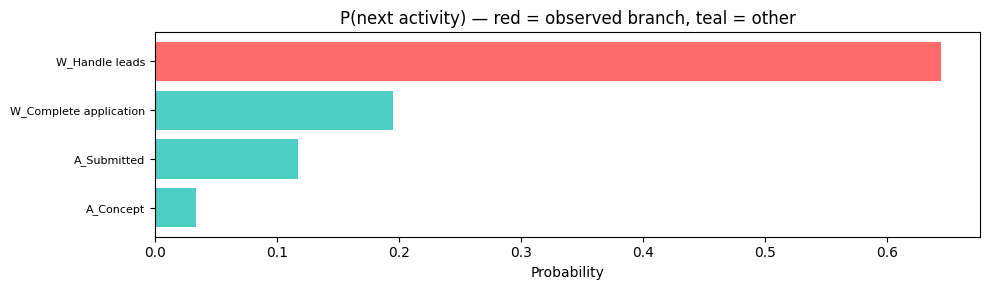

In [16]:
import matplotlib.pyplot as plt

# === Build prefix tensor from selected matching case ===
ds_idx, trace_len = matching_cases[CASE_INDEX]
cat_full, num_full, case_id = dataset[ds_idx]

prefix_len = len(PATHWAY)
pad_len = seq_len - prefix_len
src_start = seq_len - trace_len

cat_tuple = []
for c in cat_full:
    t = torch.zeros_like(c)
    t[pad_len:] = c[src_start:src_start + prefix_len]
    cat_tuple.append(t)
cat_tuple = tuple(cat_tuple)

num_tuple = []
for n in num_full:
    t = torch.zeros_like(n)
    t[pad_len:] = n[src_start:src_start + prefix_len]
    num_tuple.append(t)
num_tuple = tuple(num_tuple)

# --- Run model prediction ---
cat_in = [c.unsqueeze(0) for c in cat_tuple]
num_in = [n.unsqueeze(0) for n in num_tuple]
with torch.no_grad():
    preds = model((cat_in, num_in))[0]
    logits = preds[0][f'{ACTIVITY_FEATURE}_mean'][0]
    p = torch.softmax(logits, dim=-1).squeeze(0)
    top_p, top_idx = p.max(dim=-1)

original_pred_idx = top_idx.item()
original_pred_name = activity_names[original_pred_idx]
original_pred_prob = top_p.item()
original_probs = p.numpy()

prefix_acts = [activity_names[cat_tuple[0][j].item()] for j in range(pad_len, seq_len)]
print(f'Case: {case_id}')
print(f'Prefix: {" -> ".join(prefix_acts)}')
print(f'Model predicts: {original_pred_name} (p={original_pred_prob:.3f})')
if successors:
    branches = list(successors.keys())
    print(f'Observed branches at this point: {branches}')
print()

# Show decoded prefix
df_prefix = decoder.decode_sequence(cat_tuple, num_tuple, case_id=case_id)
display(df_prefix)

# --- Bar chart: P(next_activity) for all activities ---
nonzero_mask = original_probs > 0.005
act_labels = [activity_names[i] for i in range(len(original_probs)) if nonzero_mask[i]]
act_probs = original_probs[nonzero_mask]
sort_idx = np.argsort(act_probs)[::-1]

fig, ax = plt.subplots(figsize=(10, max(3, len(act_labels) * 0.3)))
colors = ['#FF6B6B' if act_labels[i] in successors else '#4ECDC4'
          for i in sort_idx]
ax.barh(range(len(sort_idx)), act_probs[sort_idx], color=colors)
ax.set_yticks(range(len(sort_idx)))
ax.set_yticklabels([act_labels[i] for i in sort_idx], fontsize=8)
ax.set_xlabel('Probability')
ax.set_title(f'P(next activity) — red = observed branch, teal = other')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
# === Feature sweep configuration ===

# Non-activity mutable categorical features for BPIC17
# org:resource (idx 2), case:LoanGoal (idx 5, case-level), case:ApplicationType (idx 6, case-level)
NON_ACTIVITY_MUTABLE_CAT = [2, 5, 6]
CASE_LEVEL_CAT_INDICES = [5, 6]   # LoanGoal and ApplicationType: constant across all positions

# Build valid values for each sweepable feature (exclude padding=0)
vocab_sizes = decoder.get_vocab_sizes()
valid_values = {}
for ci in NON_ACTIVITY_MUTABLE_CAT:
    feat_name = decoder.cat_features[ci]
    valid_values[ci] = list(range(1, vocab_sizes[ci]))  # skip padding
    print(f'  Feature {ci} ({feat_name}): {len(valid_values[ci])} valid values')

print(f'\nTotal sweepable features: {len(NON_ACTIVITY_MUTABLE_CAT)}')

  Feature 2 (org:resource): 150 valid values
  Feature 5 (case:LoanGoal): 15 valid values
  Feature 6 (case:ApplicationType): 3 valid values

Total sweepable features: 3


In [18]:
import time

# === Run feature sweeps (non-activity features only) ===

frozen_cat = [c.clone() for c in cat_tuple]
frozen_num_stacked = torch.stack(list(num_tuple), dim=-1)  # [seq_len, n_num]

sweep_results = []
t0 = time.time()

for ci in NON_ACTIVITY_MUTABLE_CAT:
    feat_name = decoder.cat_features[ci]
    is_case_level = ci in CASE_LEVEL_CAT_INDICES
    vals = valid_values[ci]
    N = len(vals)

    # For case-level features, position doesn't matter — sweep once
    positions = [0] if is_case_level else list(range(prefix_len))

    for pos_idx in positions:
        pos = pad_len + pos_idx

        # Build batch: N variants, one per valid value
        cat_batch = []
        for cj in range(n_cat):
            if cj == ci:
                t = frozen_cat[cj].unsqueeze(0).expand(N, -1).clone()
                for k, val in enumerate(vals):
                    if is_case_level:
                        t[k, pad_len:] = val  # ALL non-padding positions
                    else:
                        t[k, pos] = val
                cat_batch.append(t)
            else:
                cat_batch.append(frozen_cat[cj].unsqueeze(0).expand(N, -1).clone())

        num_stacked = frozen_num_stacked.unsqueeze(0).expand(N, -1, -1).clone()

        # Batch predict
        preds_batch, probs_batch = predictor.predict_batch(cat_batch, num_stacked)

        # Record results
        original_val = frozen_cat[ci][pos].item()
        for k, val in enumerate(vals):
            pred_class = int(preds_batch[k])
            sweep_results.append({
                'feature': feat_name,
                'feature_idx': ci,
                'position': pos_idx + 1,
                'is_case_level': is_case_level,
                'value_idx': val,
                'value_name': decoder.decode_categorical_value(ci, val),
                'is_original': val == original_val,
                'predicted_class': pred_class,
                'predicted_class_name': activity_names[pred_class],
                'prob_original_class': float(probs_batch[k, original_pred_idx]),
                'prob_predicted_class': float(probs_batch[k, pred_class]),
                'probability_vector': probs_batch[k].tolist(),
            })

    print(f'  {feat_name}: {len(positions)} position(s) x {N} values = {len(positions) * N} predictions')

elapsed = time.time() - t0
df_sweep = pd.DataFrame(sweep_results)
print(f'\nSweep complete: {len(df_sweep)} predictions in {elapsed:.2f}s')
print(f'  Features swept: {df_sweep["feature"].nunique()}')
print(f'  Prediction flips: {(~df_sweep["is_original"] & (df_sweep["predicted_class"] != original_pred_idx)).sum()}')

  org:resource: 2 position(s) x 150 values = 300 predictions
  case:LoanGoal: 1 position(s) x 15 values = 15 predictions
  case:ApplicationType: 1 position(s) x 3 values = 3 predictions

Sweep complete: 318 predictions in 1.75s
  Features swept: 3
  Prediction flips: 122


Analyzing 1 branches: ['W_Handle leads']
Baseline prediction: W_Handle leads (p=0.644)

Branch: "W_Handle leads" (observed frequency: 4074/4074 = 100.0%)
  Model baseline P = 0.644
  Best conditions to reach this branch:
    org:resource = User_132 -> P(W_Handle leads) = 0.646
    case:LoanGoal = Business goal -> P(W_Handle leads) = 0.645
    case:ApplicationType = Limit raise -> P(W_Handle leads) = 0.644

Top-3 feature values maximizing each branch probability:


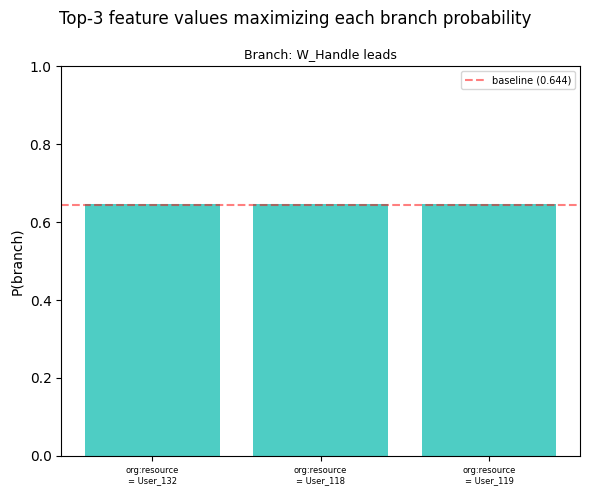

In [19]:
# === Branch-focused analysis: what conditions favor each branch? ===

branches = list(successors.keys())
branch_indices = [activity_names.index(b) for b in branches]

print(f'Analyzing {len(branches)} branches: {branches}')
print(f'Baseline prediction: {original_pred_name} (p={original_pred_prob:.3f})')
print('=' * 70)

branch_summaries = []  # for grouped bar chart

for branch, b_idx in zip(branches, branch_indices):
    baseline_p = float(original_probs[b_idx])
    total_freq = successors[branch]
    total_all = sum(successors.values())
    print(f'\nBranch: "{branch}" (observed frequency: {total_freq}/{total_all} = {total_freq/total_all*100:.1f}%)')
    print(f'  Model baseline P = {baseline_p:.3f}')
    print(f'  Best conditions to reach this branch:')

    for ci in NON_ACTIVITY_MUTABLE_CAT:
        feat_name = decoder.cat_features[ci]
        df_feat = df_sweep[df_sweep['feature_idx'] == ci].copy()

        # Compute P(branch) for each sweep row
        df_feat[f'prob_branch'] = df_feat['probability_vector'].apply(lambda pv: pv[b_idx])

        # Best value for this branch
        best_row = df_feat.loc[df_feat['prob_branch'].idxmax()]
        print(f'    {feat_name} = {best_row["value_name"]} '
              f'-> P({branch}) = {best_row["prob_branch"]:.3f}')

        branch_summaries.append({
            'branch': branch,
            'feature': feat_name,
            'best_value': best_row['value_name'],
            'prob': best_row['prob_branch'],
            'baseline_prob': baseline_p,
        })

# --- Grouped bar chart: top-3 feature values per branch ---
print('\n' + '=' * 70)
print('Top-3 feature values maximizing each branch probability:')

n_branches = len(branches)
n_cols = min(n_branches, 4)
n_rows = (n_branches + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for ax_idx, (branch, b_idx) in enumerate(zip(branches, branch_indices)):
    ax = axes_flat[ax_idx]
    baseline_p = float(original_probs[b_idx])

    # Collect all sweep rows, compute P(branch)
    df_all = df_sweep.copy()
    df_all['prob_branch'] = df_all['probability_vector'].apply(lambda pv: pv[b_idx])

    # Top-3 across all features
    top3 = df_all.nlargest(3, 'prob_branch')

    labels = [f"{row['feature']}\n= {row['value_name']}" for _, row in top3.iterrows()]
    probs = top3['prob_branch'].tolist()

    ax.bar(range(len(labels)), probs, color='#4ECDC4')
    ax.axhline(y=baseline_p, color='red', linestyle='--', alpha=0.5, label=f'baseline ({baseline_p:.3f})')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=6, ha='center')
    ax.set_title(f'Branch: {branch}', fontsize=9)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    if ax_idx % n_cols == 0:
        ax.set_ylabel('P(branch)')

# Hide unused axes
for ax_idx in range(n_branches, len(axes_flat)):
    axes_flat[ax_idx].set_visible(False)

plt.suptitle('Top-3 feature values maximizing each branch probability', fontsize=12)
plt.tight_layout()
plt.show()

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x3c5df31d0>


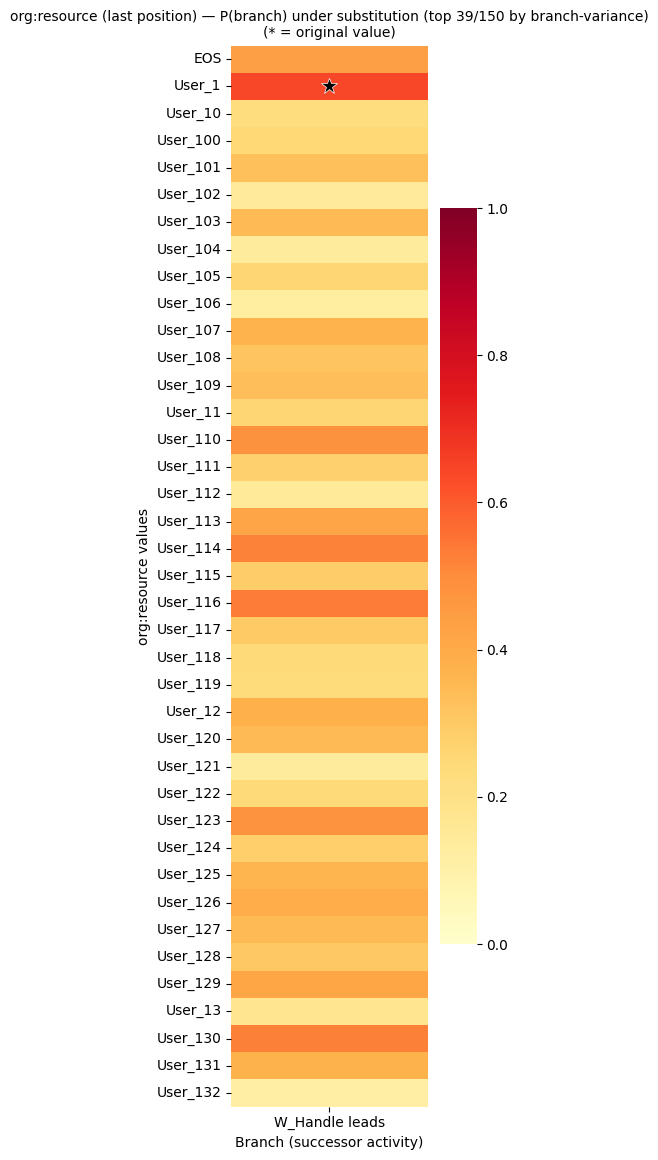

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x3c8037bf0>


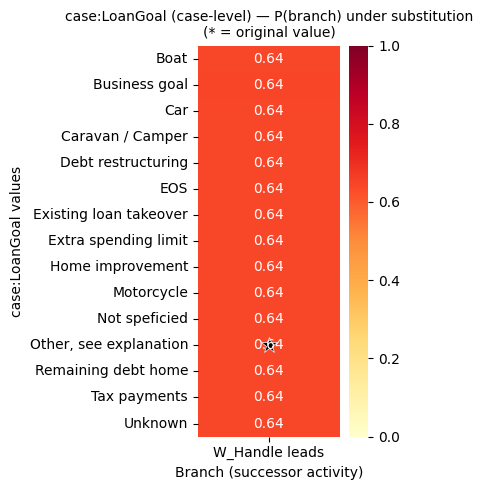

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x3c1599b80>


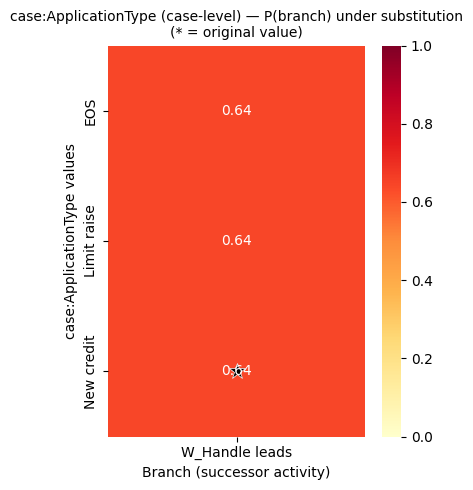

In [20]:
import seaborn as sns

# === Heatmap: feature value x branch probability ===

for ci in NON_ACTIVITY_MUTABLE_CAT:
    feat_name = decoder.cat_features[ci]
    is_case_level = ci in CASE_LEVEL_CAT_INDICES
    df_feat = df_sweep[df_sweep['feature_idx'] == ci].copy()

    # For event-level features, use last position (most impactful)
    if not is_case_level:
        last_pos = df_feat['position'].max()
        df_feat = df_feat[df_feat['position'] == last_pos]

    # Build matrix: rows = feature values, columns = branches
    heatmap_data = {}
    for branch, b_idx in zip(branches, branch_indices):
        heatmap_data[branch] = df_feat['probability_vector'].apply(lambda pv: pv[b_idx]).values

    value_labels = df_feat['value_name'].tolist()
    original_mask = df_feat['is_original'].tolist()
    hm_df = pd.DataFrame(heatmap_data, index=value_labels)

    # Sort by variance across branches (most discriminating values first)
    hm_df['_var'] = hm_df.var(axis=1)
    hm_df = hm_df.sort_values('_var', ascending=False)
    hm_df = hm_df.drop(columns='_var')

    # Limit rows for readability (large vocabs like org:resource)
    MAX_ROWS = 40
    if len(hm_df) > MAX_ROWS:
        # Keep original value even if not in top-N
        top_rows = hm_df.head(MAX_ROWS - 1)
        orig_values = [vl for vl, om in zip(value_labels, original_mask) if om]
        for ov in orig_values:
            if ov in hm_df.index and ov not in top_rows.index:
                top_rows = pd.concat([top_rows, hm_df.loc[[ov]]])
        title_suffix = f' (top {len(top_rows)}/{len(hm_df)} by branch-variance)'
        hm_df = top_rows
    else:
        title_suffix = ''

    fig, ax = plt.subplots(figsize=(max(4, len(branches) * 2), max(5, len(hm_df) * 0.3)))
    sns.heatmap(
        hm_df, annot=len(hm_df) <= 30, fmt='.2f', cmap='YlOrRd',
        vmin=0, vmax=1, ax=ax,
        xticklabels=True, yticklabels=True,
    )

    # Mark original value with a star
    for row_idx, (val_name, is_orig) in enumerate(zip(value_labels, original_mask)):
        if is_orig and val_name in hm_df.index:
            y_pos = list(hm_df.index).index(val_name)
            for col_idx in range(len(branches)):
                ax.plot(col_idx + 0.5, y_pos + 0.5, marker='*', color='black',
                        markersize=12, markeredgecolor='white', markeredgewidth=0.5)

    pos_label = ' (last position)' if not is_case_level else ' (case-level)'
    ax.set_xlabel('Branch (successor activity)')
    ax.set_ylabel(f'{feat_name} values')
    ax.set_title(f'{feat_name}{pos_label} — P(branch) under substitution{title_suffix}\n'
                 f'(* = original value)', fontsize=10)
    plt.tight_layout()
    plt.show()